In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import json

results_dir = "results"
result_files = glob.glob(os.path.join(results_dir, "*.json"))

In [2]:
def load_result(seed):
    result = {}
    
    orig_path = os.path.join(results_dir, "llama2-7b.json")

    result["orig"] = json.load(open(orig_path, "r"))
    for component in ["qk", "ov"]:
        for shuffle_type in ["inside", "outside"]:
            pth = os.path.join(
                results_dir, 
                f"llama2-7b_{shuffle_type}_shuffled_{component}_{seed}.json"
            )
            result[f"{component}_{shuffle_type}"] = json.load(open(pth, "r"))   
    
    return result

In [3]:
seed = 20
result = load_result(seed)

pred_probs = np.exp([example["pred_logprob"] for example in result["orig"]["examples"]])
qk_inside_probs = np.exp([example["pred_logprob"] for example in result["qk_inside"]["examples"]])
qk_outside_probs = np.exp([example["pred_logprob"] for example in result["qk_outside"]["examples"]])
ov_inside_probs = np.exp([example["pred_logprob"] for example in result["ov_inside"]["examples"]])
ov_outside_probs = np.exp([example["pred_logprob"] for example in result["ov_outside"]["examples"]])

print("============= Pred probs")
print("original", np.mean(pred_probs))
print("qk_inside", np.mean(qk_inside_probs))
print("qk_outside", np.mean(qk_outside_probs))
print("ov_inside", np.mean(ov_inside_probs))
print("ov_outside", np.mean(ov_outside_probs))

pred_correct = np.array([example["correct"] for example in result["orig"]["examples"]])
qk_inside_correct = np.array([example["correct"] for example in result["qk_inside"]["examples"]])
qk_outside_correct = np.array([example["correct"] for example in result["qk_outside"]["examples"]])
ov_inside_correct = np.array([example["correct"] for example in result["ov_inside"]["examples"]])
ov_outside_correct = np.array([example["correct"] for example in result["ov_outside"]["examples"]])

print("\n============= Pred acc")
print("original", np.mean(pred_correct))
print("qk_inside", np.mean(qk_inside_correct))
print("qk_outside", np.mean(qk_outside_correct))
print("ov_inside", np.mean(ov_inside_correct))
print("ov_outside", np.mean(ov_outside_correct))

============= Pred probs
original 0.6245591509249071
qk_inside 0.47331497051512755
qk_outside 0.3566173306527961
ov_inside 0.48690827446393087
ov_outside 0.3637577966082348

============= Pred acc
original 0.92
qk_inside 0.83
qk_outside 0.54
ov_inside 0.84
ov_outside 0.65


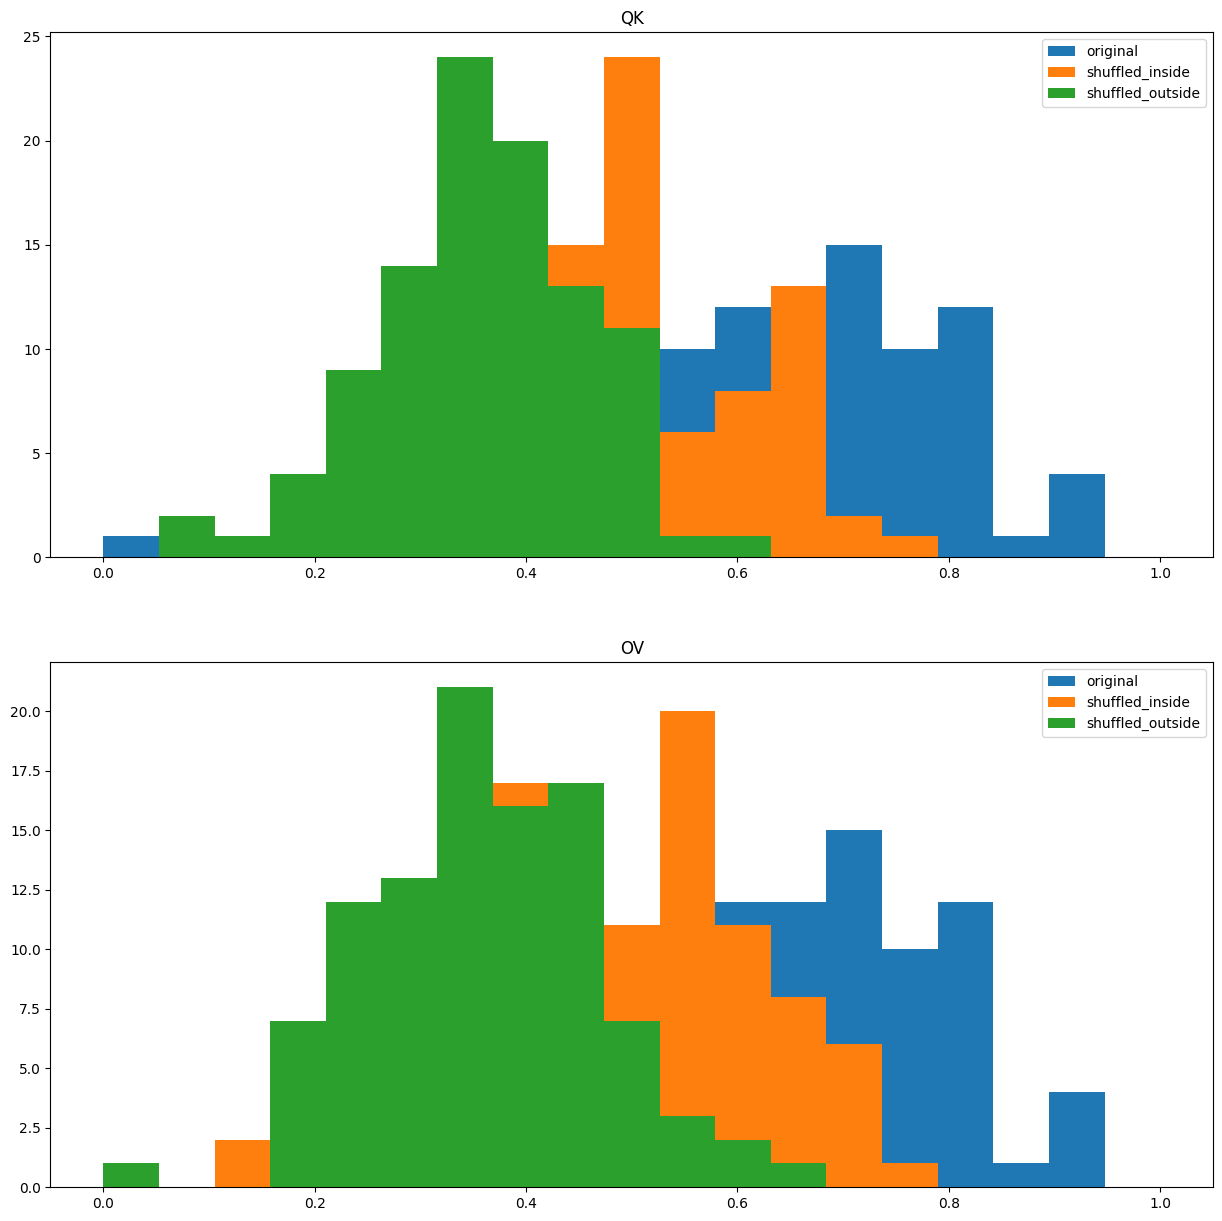

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(15, 15))
bins = np.linspace(0, 1, 20)
axs[0].hist(pred_probs, bins=bins, density=True, label="original")
axs[0].hist(qk_inside_probs, bins=bins, density=True, label="shuffled_inside")
axs[0].hist(qk_outside_probs, bins=bins, density=True, label="shuffled_outside")

axs[1].hist(pred_probs, bins=bins, density=True, label="original")
axs[1].hist(ov_inside_probs, bins=bins, density=True, label="shuffled_inside")
axs[1].hist(ov_outside_probs, bins=bins, density=True, label="shuffled_outside")

axs[1].legend()
axs[0].legend()

axs[0].set_title("QK")
axs[1].set_title("OV")
plt.show()